In [2]:

import os

CIRCLES_OS_PATH = 'data/circles/'
RECTANGLES_OS_PATH = 'data/rectangles/'
TRIANGLES_OS_PATH = 'data/triangles/'
MODELS_DIR = 'models/'

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

import random

import glob


# Set seed for experimental reproducibility
seed = 1
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1783693666.230224 1303100 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783693669.950110 1303100 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Import Dataset

triangle


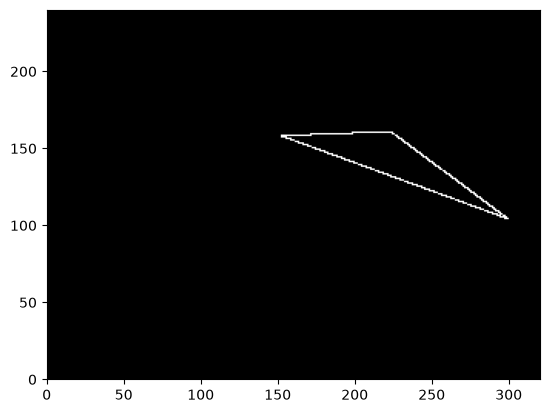

In [3]:
SAMPLES = 2500
WIDTH = 240 # Change as needed
HEIGHT = 320 # Changed as needed
np.set_printoptions(threshold=np.inf)

def show_screen(axs, screen):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,320,0,240))

label_array = ["circle", "rectangle", "triangle"]
label_to_index = dict((name, index) for index,name in enumerate(label_array))

def get_img(img_path):
    return np.load(img_path)

# Create tuple of whole dataset
def get_ds(data_path):
    labels = np.zeros(SAMPLES*3)
    images = np.zeros((SAMPLES*3, WIDTH, HEIGHT))
    img_paths = list()

    for img_path in glob.glob(F'{data_path}/**/*'):
        img_paths.append(img_path)
  
    random.shuffle(img_paths)
    for i, img_path in enumerate(img_paths):
        images[i] = get_img(img_path)
        head, tail = os.path.split(img_path)
        label_id = tail.split('-')[0]
        labels[i] = label_to_index[label_id]
    
    return images, labels


TRAIN_SPLIT = int(0.6*(SAMPLES*3))
TEST_SPLIT = int(0.2*(SAMPLES*3) + TRAIN_SPLIT)

full_x, full_y = get_ds('data')

x_train, x_test, x_validate = np.split(full_x, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(full_y, [TRAIN_SPLIT, TEST_SPLIT])

show_screen(plt, x_validate[4])
print(label_array[int(y_validate[4])])




# Create The Model

In [4]:

#model = tf.keras.Sequential([
#    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#   tf.keras.layers.Flatten(),
#    tf.keras.layers.Dense(64, activation='relu'),
#    tf.keras.layers.Dense(3)
#])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    #tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    #tf.keras.layers.Dropout(0.3),
    #tf.keras.layers.Softmax(),
    tf.keras.layers.Dense(3, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001)),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 238, 318, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 119, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 117, 157, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 58, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 76, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 34048)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │       102,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,963 (472.51 KB)

 Trainable params: 120,963 (472.51 KB)

 Non-trainable params: 0 (0.00 B)

## Train The Model

In [5]:
history = model.fit(
    x_train, y_train, epochs=7, batch_size=64, validation_data=(x_validate, y_validate)
)

Epoch 1/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 964ms/step - accuracy: 0.6500 - loss: 0.7391 - val_accuracy: 0.7753 - val_loss: 0.4945
Epoch 2/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 935ms/step - accuracy: 0.8327 - loss: 0.4127 - val_accuracy: 0.7987 - val_loss: 0.4604
Epoch 3/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 933ms/step - accuracy: 0.8709 - loss: 0.3513 - val_accuracy: 0.8067 - val_loss: 0.4715
Epoch 4/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 67s 940ms/step - accuracy: 0.8933 - loss: 0.3127 - val_accuracy: 0.8073 - val_loss: 0.5073
Epoch 5/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 67s 948ms/step - accuracy: 0.9073 - loss: 0.2750 - val_accuracy: 0.8080 - val_loss: 0.5607
Epoch 6/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 935ms/step - accuracy: 0.9202 - loss: 0.2484 - val_accuracy: 0.8160 - val_loss: 0.5437
Epoch 7/7
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 934ms/step - accuracy: 0.9236 - loss: 0.2466 - val_accuracy: 0.8167 - val_loss: 0.5678


In [6]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(F'Test Complete (Loss: {loss:.4f}, Accuracy: {acc:.4f})')

Test Complete (Loss: 0.6202, Accuracy: 0.8327)


In [7]:
predictions = model.predict(x_test)
i = 0
number_correct = 0
for element in predictions:
    most_probable = max(element)
    if most_probable == element[0]:
        print(F'circle - {label_array[int(y_test[i])]}')
        if int(y_test[i]) == 0:
            number_correct += 1
    elif most_probable == element[1]:
        print(F'rectangle - {label_array[int(y_test[i])]}')
        if int(y_test[i]) == 1:
            number_correct += 1
    else:
        print(F'triangle - {label_array[int(y_test[i])]}')
        if int(y_test[i]) == 2:
            number_correct += 1
    i += 1

print(F'Number Correct = {number_correct}/{int((SAMPLES*3)*0.2)} ({(number_correct/int((SAMPLES*3)*0.2)*100):.0f}%)')


47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step
circle - circle
circle - circle
rectangle - rectangle
circle - triangle
rectangle - rectangle
triangle - triangle
rectangle - rectangle
triangle - triangle
triangle - triangle
triangle - triangle
circle - circle
circle - circle
triangle - triangle
triangle - triangle
circle - circle
triangle - circle
rectangle - rectangle
triangle - triangle
rectangle - rectangle
triangle - triangle
rectangle - rectangle
rectangle - rectangle
circle - triangle
rectangle - rectangle
circle - triangle
rectangle - rectangle
triangle - triangle
circle - triangle
circle - circle
rectangle - rectangle
triangle - triangle
circle - circle
triangle - triangle
circle - circle
circle - circle
triangle - triangle
circle - circle
circle - circle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
circle - circle
rectangle - rectangle
triangle - triangle
triangle - triangle
circle - circle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectang

# Convert to TfLite Model